ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКА ДАНИХ

In [1]:
#Імпорт бібліотек
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Завантаження даних
df = pd.read_csv("synthetic_coffee_health_10000.csv")
df = df.drop(columns=['ID'])

#Вибір ознак і цільової змінної
y = df['Health_Issues']
X = df.drop(columns=['Health_Issues'])

#Кодування цільової змінної
le = LabelEncoder()
y = le.fit_transform(y)

FEATURE ENGINEERING

In [3]:
#Створення нових інформативних ознак
X['Coffee_Sleep_Interaction'] = X['Coffee_Intake'] * X['Sleep_Hours']
X['Caffeine_per_Hour'] = X['Caffeine_mg'] / (X['Sleep_Hours'] + 1)
X['Age_Binned'] = pd.cut(X['Age'], bins=[18, 30, 50, 80],
                          labels=['Young', 'Middle', 'Old'])

#One-Hot Encoding категоріальних змінних
cat_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level',
            'Occupation', 'Smoking', 'Alcohol_Consumption', 'Age_Binned']
X = pd.get_dummies(X, columns=cat_cols)

#Масштабування числових ознак
num_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
            'BMI', 'Heart_Rate', 'Physical_Activity_Hours',
            'Coffee_Sleep_Interaction', 'Caffeine_per_Hour']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

#Обробка можливих пропусків
X = X.fillna(0)

DECISION TREE

In [4]:
class MyDecisionTree:
    def __init__(self, max_depth=8, min_samples=5):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.tree = None
        self.feature_importance = None
        self.n_total = 0

    
    #Gini Index
    def gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        p = [np.sum(y == c) / m for c in np.unique(y)]
        return 1 - sum(pi ** 2 for pi in p)

    #Пошук найкращого розбиття
    def best_split(self, X, y):
        best_gini = float('inf')
        best_feature, best_threshold = None, None
        parent_gini = self.gini(y)
        m, n = X.shape

        for feature in range(n):
            thresholds = np.unique(X[:, feature])
            for t in thresholds:
                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]
                if len(left) == 0 or len(right) == 0:
                    continue
                g = (len(left)/m) * self.gini(left) + (len(right)/m) * self.gini(right)
                if g < best_gini:
                    best_gini = g
                    best_feature, best_threshold = feature, t

        gini_gain = parent_gini - best_gini
        return best_feature, best_threshold, gini_gain

    #Рекурсивна побудова дерева
    def build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples:
            return {'leaf': True, 'class': Counter(y).most_common(1)[0][0]}

        feature, threshold, gain = self.best_split(X, y)
        if feature is None:
            return {'leaf': True, 'class': Counter(y).most_common(1)[0][0]}

        self.feature_importance[feature] += gain * len(y) / self.n_total

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': self.build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self.build_tree(X[right_mask], y[right_mask], depth + 1),
            'class': Counter(y).most_common(1)[0][0]
        }

    #Навчання моделі
    def fit(self, X, y):
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        if self.feature_importance.sum() > 0:
            self.feature_importance /= self.feature_importance.sum()
        return self

    #Прогноз для одного зразка
    def predict_one(self, x, node=None):
        node = self.tree if node is None else node
        if node['leaf']:
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        return self.predict_one(x, node['right'])

    #Прогноз для множини зразків
    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

FEATURE SELECTION

In [5]:
tree_fs = MyDecisionTree(max_depth=8)
tree_fs.fit(X.values, y)

importances = pd.Series(
    tree_fs.feature_importance, index=X.columns
).sort_values(ascending=False)

selected_features = importances.head(10).index
X = X[selected_features]

TRAIN / VALIDATION / TEST SPLIT

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

НАВЧАННЯ ДЕРЕВА

In [7]:
tree = MyDecisionTree(max_depth=8)
tree.fit(X_train.values, y_train)

y_pred = tree.predict(X_test.values)

print("=== MyDecisionTree ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print("MCC:", matthews_corrcoef(y_test, y_pred))

=== MyDecisionTree ===
Accuracy: 0.9966666666666667
F1-score: 0.9966636788048554
MCC: 0.9935525299443477


SKLEARN DECISION TREE

In [8]:
dt_sk = DecisionTreeClassifier(criterion='gini', max_depth=8, random_state=42)
dt_sk.fit(X_train, y_train)
y_sk = dt_sk.predict(X_test)

RANDOM FOREST

In [9]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

CONFUSION MATRICES

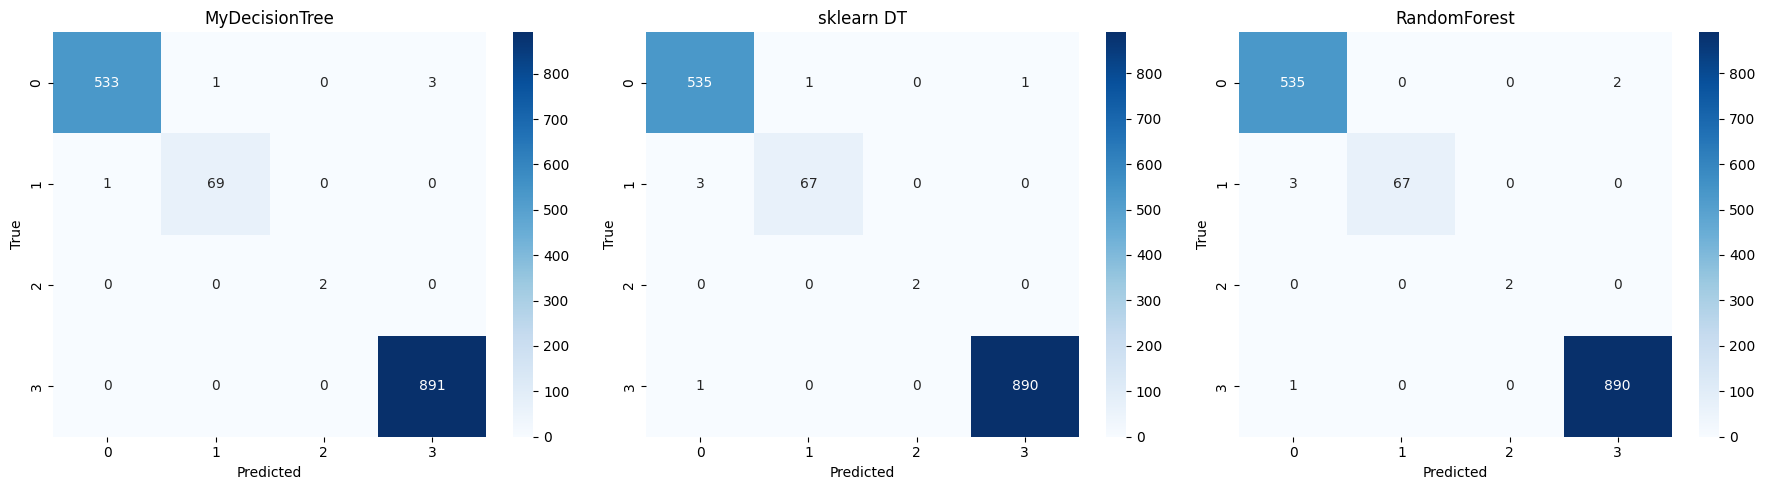

In [10]:
models = {
    "MyDecisionTree": y_pred,
    "sklearn DT": y_sk,
    "RandomForest": y_rf
}

plt.figure(figsize=(18, 5))
for i, (name, pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, pred)
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE: MyDecisionTree vs RandomForest

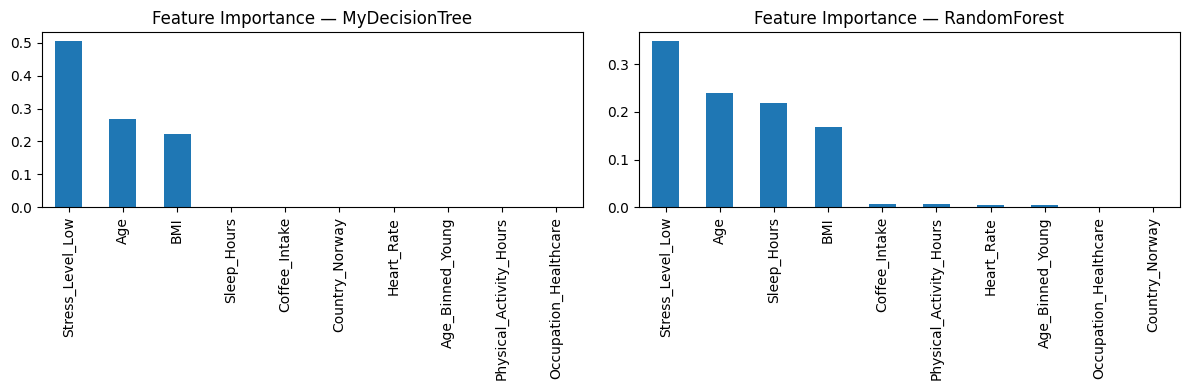

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
importances.head(10).plot(kind='bar')
plt.title("Feature Importance — MyDecisionTree")

plt.subplot(1,2,2)
pd.Series(rf.feature_importances_, index=X.columns)\
    .sort_values(ascending=False).head(10)\
    .plot(kind='bar')
plt.title("Feature Importance — RandomForest")

plt.tight_layout()
plt.show()

5-FOLD CROSS-VALIDATION

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, test_idx in skf.split(X.values, y):
    model = MyDecisionTree(max_depth=8)
    model.fit(X.values[train_idx], y[train_idx])
    preds = model.predict(X.values[test_idx])
    cv_scores.append(accuracy_score(y[test_idx], preds))

print("5-Fold CV Accuracy (MyDecisionTree):", np.mean(cv_scores))

5-Fold CV Accuracy (MyDecisionTree): 0.9981
